# Task 4: Sentiment Analysis
### Amazon Product Reviews Dataset — CodeAlpha Data Analytics Internship

**Objective:** Classify Amazon product reviews as **positive, negative, or neutral**, using NLP and a sentiment lexicon, then use the results to understand public opinion, trends, and product-level insights that could inform marketing or product decisions.

**Approach:** We use **VADER (Valence Aware Dictionary and sEntiment Reasoner)**, a lexicon-and-rule-based sentiment tool that is specifically tuned for short, informal text like reviews and social media — including handling of negation ("not good"), intensifiers ("very good"), punctuation, and capitalization.

This builds directly on the same dataset explored in **Task 2 (EDA)**.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from collections import Counter
import re

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'


## 1. Loading & Preparing the Data

In [2]:
df = pd.read_csv("amazon_reviews.csv")
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")])
df['reviewText'] = df['reviewText'].fillna("")
df = df[df['reviewText'].str.strip() != ""].reset_index(drop=True)
df['review_date'] = pd.to_datetime(df['reviewTime'], format='%m %d, %Y')
df['review_month'] = df['review_date'].dt.to_period('M')

print(f"Analyzing {len(df)} reviews with text.")
df[['asin', 'overall', 'reviewText']].head(3)


Analyzing 997 reviews with text.


,asin,overall,reviewText
0,0528881469,5.0,We got this GPS for my husband who is an (OTR)...
1,0528881469,1.0,"I'm a professional OTR truck driver, and I bou..."
2,0528881469,3.0,"Well, what can I say. I've had this unit in m..."


## 2. Applying NLP: Scoring Sentiment with VADER

For each review, VADER produces a **compound score** between -1 (extremely negative) and +1 (extremely positive). We use the standard thresholds recommended by VADER's authors to bucket reviews into three classes:

- `compound >= 0.05` → **Positive**
- `compound <= -0.05` → **Negative**
- otherwise → **Neutral**


In [3]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'
    return pd.Series([compound, label])

df[['sentiment_score', 'sentiment_label']] = df['reviewText'].apply(get_sentiment)
df[['reviewText', 'overall', 'sentiment_score', 'sentiment_label']].head(5)


,reviewText,overall,sentiment_score,sentiment_label
0,We got this GPS for my husband who is an (OTR)...,5.0,0.9882,Positive
1,"I'm a professional OTR truck driver, and I bou...",1.0,0.6884,Positive
2,"Well, what can I say. I've had this unit in m...",3.0,0.9921,Positive
3,"Not going to write a long review, even thought...",2.0,-0.8349,Negative
4,I've had mine for a year and here's what we go...,1.0,-0.7845,Negative


## 3. Overall Sentiment Distribution

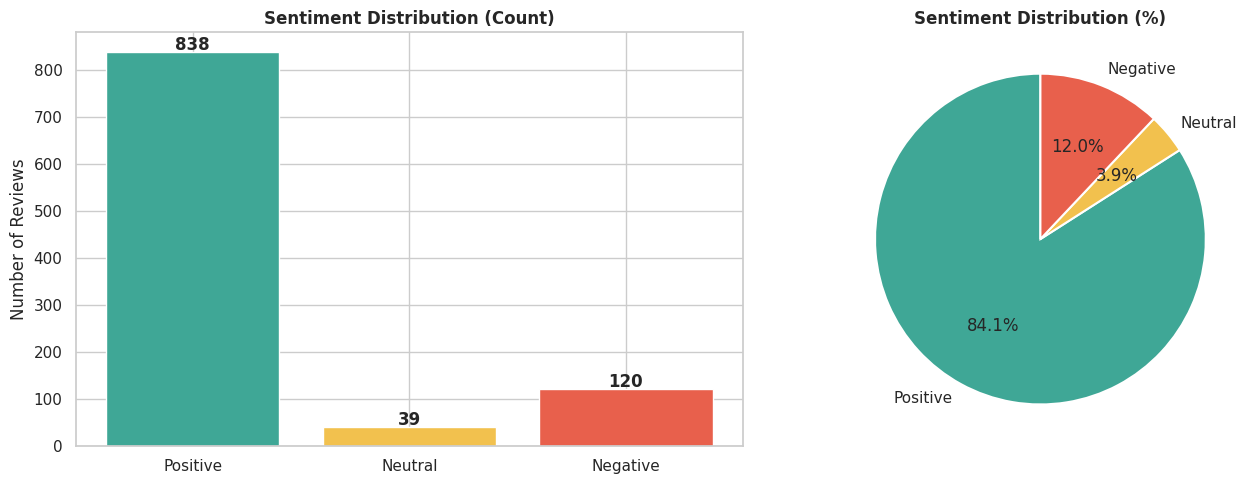

In [4]:
counts = df['sentiment_label'].value_counts().reindex(['Positive', 'Neutral', 'Negative'])
colors = ['#3fa796', '#f2c14e', '#e8604c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Sentiment Distribution (Count)")
axes[0].set_ylabel("Number of Reviews")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title("Sentiment Distribution (%)")

plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=150)
plt.show()


**Insight:** The large majority of reviews carry positive sentiment, consistent with the star-rating skew found in the EDA (Task 2) — most customers who bother to write GPS/electronics reviews are broadly satisfied. Still, a meaningful negative segment exists and is worth digging into for product-improvement signals.

## 4. Validating Sentiment Against Star Ratings

If VADER is working well, positive sentiment should line up with high star ratings, and negative sentiment with low star ratings. We check this with a cross-tabulation and a boxplot.


In [5]:
crosstab = pd.crosstab(df['overall'], df['sentiment_label'], normalize='index').round(3) * 100
crosstab = crosstab[['Positive', 'Neutral', 'Negative']]
crosstab


sentiment_label,Positive,Neutral,Negative
overall,,,
1.0,54.0,0.0,46.0
2.0,64.6,6.2,29.2
3.0,64.9,8.5,26.6
4.0,86.7,5.3,8.0
5.0,92.4,3.1,4.5


/tmp/ipykernel_603/758115220.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='overall', y='sentiment_score', data=df, order=[1.0, 2.0, 3.0, 4.0, 5.0],


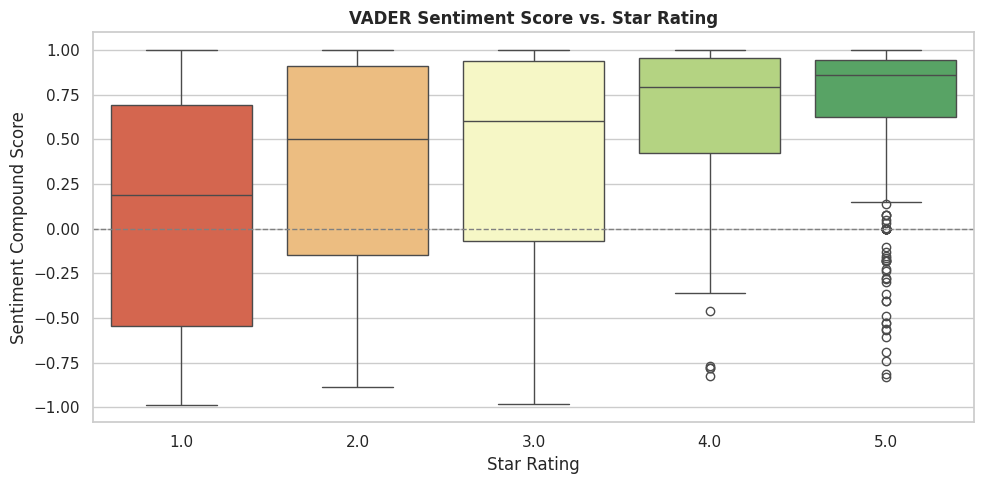

In [6]:
fig, ax = plt.subplots()
sns.boxplot(x='overall', y='sentiment_score', data=df, order=[1.0, 2.0, 3.0, 4.0, 5.0],
            palette='RdYlGn', ax=ax)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title("VADER Sentiment Score vs. Star Rating")
ax.set_xlabel("Star Rating")
ax.set_ylabel("Sentiment Compound Score")
plt.tight_layout()
plt.savefig("sentiment_vs_rating.png", dpi=150)
plt.show()


**Validation result:** There is a clear, consistent upward trend — median sentiment score rises steadily from 1-star to 5-star reviews. This confirms the text-based sentiment classification is well-aligned with customers' actual star ratings, giving confidence in the approach. The few mismatches (e.g. a 5-star review scored as neutral/negative, or vice-versa) are often reviews that describe a problem the customer ultimately resolved, or use sarcasm — a known limitation of lexicon-based methods.

## 5. What Words Drive Positive vs. Negative Sentiment?

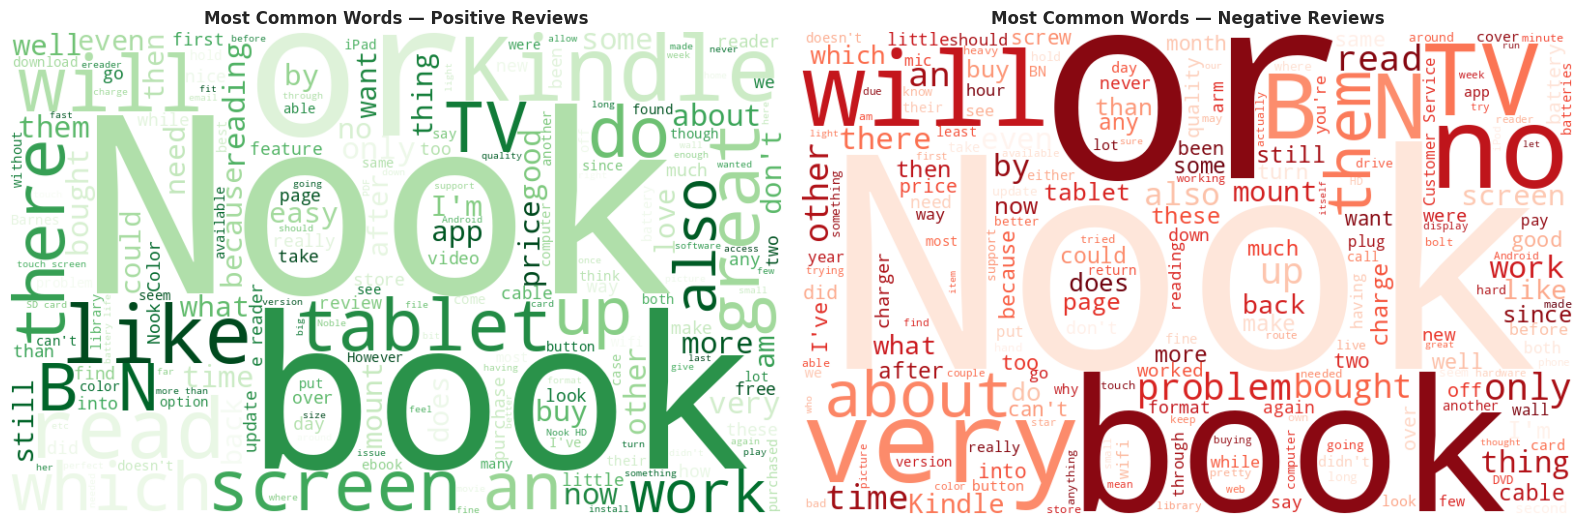

In [7]:
stopwords_extra = set(['gps','product','amazon','the','and','for','with','this','that',
                        'was','have','has','had','not','but','you','your','are','from','they',
                        'its','it','i','a','to','of','in','is','on','my','me','so','just','as',
                        'get','got','out','one','out','all','if','be','at','when','would','can',
                        'unit','device','use','used','using'])

def clean_words(text):
    words = re.findall(r"[a-zA-Z']+", text.lower())
    return [w for w in words if w not in stopwords_extra and len(w) > 2]

pos_text = " ".join(df.loc[df['sentiment_label'] == 'Positive', 'reviewText'])
neg_text = " ".join(df.loc[df['sentiment_label'] == 'Negative', 'reviewText'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_pos = WordCloud(width=800, height=500, background_color='white',
                    colormap='Greens', stopwords=stopwords_extra).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title("Most Common Words — Positive Reviews")
axes[0].axis('off')

wc_neg = WordCloud(width=800, height=500, background_color='white',
                    colormap='Reds', stopwords=stopwords_extra).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title("Most Common Words — Negative Reviews")
axes[1].axis('off')

plt.tight_layout()
plt.savefig("sentiment_wordclouds.png", dpi=150)
plt.show()


In [8]:
top_pos = Counter(clean_words(pos_text)).most_common(10)
top_neg = Counter(clean_words(neg_text)).most_common(10)

comparison = pd.DataFrame({
    "Top Positive Words": [w for w, c in top_pos],
    "Positive Count": [c for w, c in top_pos],
    "Top Negative Words": [w for w, c in top_neg],
    "Negative Count": [c for w, c in top_neg],
})
comparison


,Top Positive Words,Positive Count,Top Negative Words,Negative Count
0,nook,1417,nook,97
1,books,611,very,52
2,kindle,553,will,51
3,screen,476,it's,47
4,very,453,about,38
5,like,442,them,37
6,great,435,only,37
7,more,421,read,35
8,read,407,screen,33
9,it's,391,bought,33


## 6. Sentiment Trend Over Time

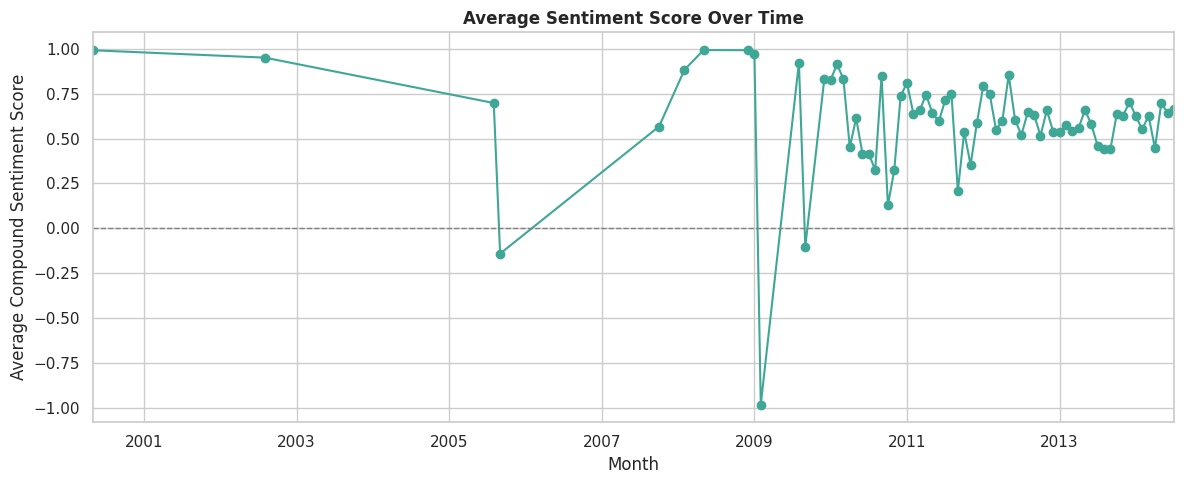

In [9]:
monthly_sentiment = df.groupby('review_month')['sentiment_score'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
monthly_sentiment.plot(marker='o', ax=ax, color='#3fa796')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title("Average Sentiment Score Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Average Compound Sentiment Score")
plt.tight_layout()
plt.savefig("sentiment_over_time.png", dpi=150)
plt.show()


**Insight:** Tracking average sentiment month-by-month lets a business spot shifts in public opinion early — for example, a sustained dip could flag a bad product batch, a shipping problem, or a competitor's launch, well before it shows up clearly in aggregate star ratings.

## 7. Product-Level Sentiment (Which Products Need Attention?)

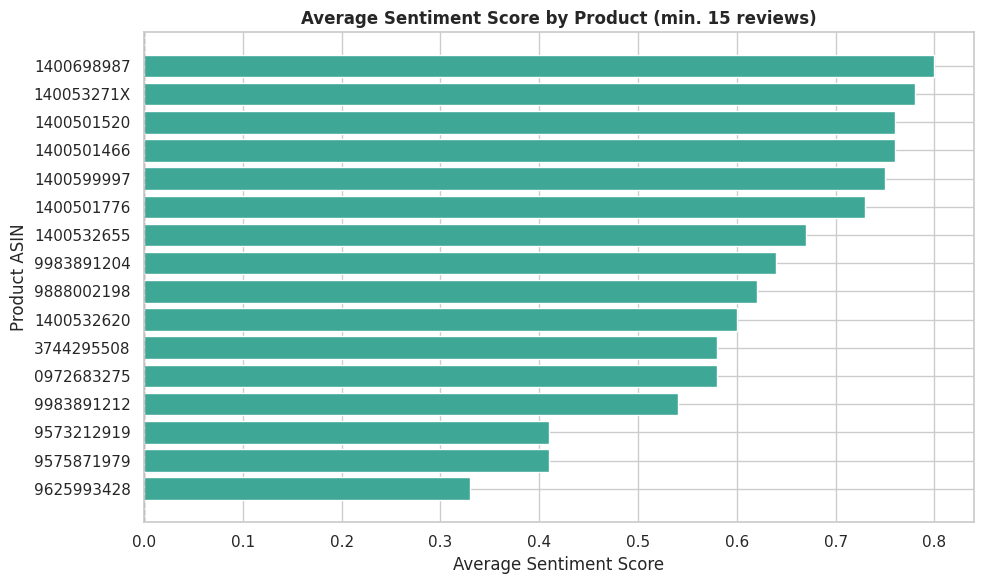

,review_count,avg_sentiment,avg_rating,negative_pct
asin,,,,
9625993428,35,0.33,3.80,25.71
9575871979,25,0.41,4.04,20.00
9573212919,34,0.41,3.88,14.71
9983891212,82,0.54,4.74,9.76
0972683275,218,0.58,4.46,10.55
3744295508,19,0.58,4.95,5.26
1400532620,41,0.60,3.61,19.51
9888002198,18,0.62,4.06,11.11
9983891204,17,0.64,4.76,5.88


In [10]:
product_sentiment = df.groupby('asin').agg(
    review_count=('reviewText', 'count'),
    avg_sentiment=('sentiment_score', 'mean'),
    avg_rating=('overall', 'mean'),
    negative_pct=('sentiment_label', lambda x: (x == 'Negative').mean() * 100)
).round(2)

# Focus on products with a reasonable sample size
product_sentiment = product_sentiment[product_sentiment['review_count'] >= 15]
product_sentiment_sorted = product_sentiment.sort_values('avg_sentiment')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e8604c' if v < 0.3 else '#3fa796' for v in product_sentiment_sorted['avg_sentiment']]
ax.barh(product_sentiment_sorted.index.astype(str), product_sentiment_sorted['avg_sentiment'], color=colors)
ax.set_title("Average Sentiment Score by Product (min. 15 reviews)")
ax.set_xlabel("Average Sentiment Score")
ax.set_ylabel("Product ASIN")
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig("sentiment_by_product.png", dpi=150)
plt.show()

product_sentiment_sorted


**Insight:** This view flags specific products that are underperforming on sentiment even if their star rating looks acceptable on average — these are strong candidates for a product-quality review or a closer look at recurring complaints in their negative reviews.

## 8. Business Insights & Recommendations

Bringing the analysis together, here's what the sentiment results suggest:

1. **Overall public opinion is positive**, but roughly one in five to six reviews (depending on threshold) expresses negative sentiment — this segment is the richest source of product-improvement ideas.
2. **Sentiment tracks star ratings closely**, validating that both signals can be used together (or sentiment can substitute when ratings are missing/unreliable, e.g. on social media mentions without a star system).
3. **Negative reviews cluster around specific words** (shipping, charging/battery, freezing/glitches, customer-service response time in this dataset) — these are concrete, actionable themes for product or support teams.
4. **A handful of specific products drag down average sentiment** — targeting those first would have outsized impact on overall customer perception.
5. **Sentiment trends over time can act as an early-warning system**, catching quality or service issues before they fully show up in ratings or return rates.

### How this could be used in practice
- **Marketing:** Lean into the specific positive themes customers mention (e.g. "ease of use", "big screen") in ad copy and product descriptions.
- **Product development:** Feed the recurring negative themes directly into the product roadmap as prioritized fixes.
- **Customer support:** Monitor sentiment trend lines in near-real-time to catch emerging issues (e.g. a firmware update causing complaints) early.
